# 05 · Volatility forecasting

**Question.** Can a model forecast a stock's realized volatility over the next 5 and 21 trading days better than the standard naive forecasts, when evaluated honestly?

Volatility is forecast for risk measurement. Nothing here predicts prices or the direction of returns, and nothing is a trading signal. All results are read from the stored run (`python scripts/run_ml.py`); nothing is retrained in this notebook.

*FinSight is an analytics tool, not investment advice.*

## 1. Data

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import text

from src.database import queries
from src.database.connection import get_engine
from src.formatting import format_crore, format_metric, format_pct

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})
ACCENT, GREY = "#1f4e79", "#8c8c8c"

with get_engine().connect() as conn:
    companies = queries.load_companies(conn)
    metrics = queries.load_metrics(conn)
    statements = queries.load_statements(conn)
    prices = queries.load_prices(conn)
    as_of = queries.load_latest_price_date(conn).iloc[0]["latest"]
firms = companies[companies["entity_type"] == "company"].reset_index(drop=True)
short = lambda t: t.replace(".NS", "")
print(f"{len(firms)} companies in {firms['sector_name'].nunique()} sectors | "
      f"{len(metrics):,} stored metric rows | prices to {as_of}")

with get_engine().connect() as conn:
    run = pd.read_sql(text("SELECT * FROM core.ml_runs WHERE task = 'volatility'"), conn).iloc[0]
    by_ticker = queries.load_ml_metrics(conn, "ticker")
    by_fold = queries.load_ml_metrics(conn, "fold")
comparison = pd.DataFrame(run["results"]["comparison"])
dm = pd.DataFrame(run["results"]["dm"])
folds = pd.DataFrame(run["results"]["folds"])
params = run["params"]
print(f"Run seed {run['seed']}, data snapshot {run['data_snapshot_id']}, "
      f"{params['tickers']} companies.")
print("Features:", ", ".join(params["features"]))

25 companies in 5 sectors | 6,146 stored metric rows | prices to 2026-10-06
Run seed 42, data snapshot 2dca6b196267, 25 companies.
Features: log_rv_1, log_rv_5, log_rv_21, log_rv_63, abs_return, log_volume_ratio, log_parkinson_5, log_parkinson_21, mkt_log_rv_5, mkt_log_rv_21


## 2. Method

| | |
|---|---|
| Target | Realized variance over t+1 .. t+h (mean of squared daily returns), h = 5, 21 |
| Baselines | Trailing 21-day realized variance; EWMA (RiskMetrics, λ = 0.94) |
| Models | GARCH(1,1); ridge regression; gradient-boosted trees (the last two pooled across companies) |
| Validation | Walk-forward, expanding window, quarterly test blocks, models refit each block |
| Metrics | RMSE, MAE (annualized volatility), QLIKE (variance); Diebold–Mariano test |

**Leakage controls.** Features at date t use only data up to t. The last h training rows before each cutoff are purged, because their targets extend into the test block. Hyperparameters are fixed, not tuned. `tests/test_ml.py` alters all data after a date and checks that every forecaster's output up to that date is unchanged.

In [2]:
show = folds[folds["horizon"] == 5][["fold", "train_start", "train_end", "cutoff",
                                    "test_start", "test_end", "train_dates", "test_rows"]]
print("Walk-forward folds, 5-day horizon (train_end is 5 trading days before the cutoff: the purge)")
print(show.to_string(index=False))
ok = (pd.to_datetime(folds["test_start"]) > pd.to_datetime(folds["cutoff"])).all() and \
     (pd.to_datetime(folds["train_end"]) < pd.to_datetime(folds["cutoff"])).all()
print(f"\nEvery test block starts after its cutoff, and every training window ends before it: {ok}")

Walk-forward folds, 5-day horizon (train_end is 5 trading days before the cutoff: the purge)
 fold train_start  train_end     cutoff test_start   test_end  train_dates  test_rows
    1  2021-10-06 2023-10-10 2023-10-17 2023-10-18 2024-01-18          499       1574
    2  2021-10-06 2024-01-11 2024-01-18 2024-01-19 2024-04-25          562       1575
    3  2021-10-06 2024-04-18 2024-04-25 2024-04-26 2024-07-29          625       1575
    4  2021-10-06 2024-07-22 2024-07-29 2024-07-30 2024-10-28          688       1575
    5  2021-10-06 2024-10-21 2024-10-28 2024-10-29 2025-01-28          751       1575
    6  2021-10-06 2025-01-21 2025-01-28 2025-01-29 2025-05-05          814       1551
    7  2021-10-06 2025-04-25 2025-05-05 2025-05-06 2025-07-31          877       1575
    8  2021-10-06 2025-07-24 2025-07-31 2025-08-01 2025-11-03          940       1574
    9  2021-10-06 2025-10-27 2025-11-03 2025-11-04 2026-02-04         1003       1575
   10  2021-10-06 2026-01-28 2026-02-04 2026-02

## 3. Results

### 3.1 Models against the baselines

In [3]:
labels = {"hist_21": "Trailing 21-day (baseline)", "ewma": "EWMA (baseline)",
          "garch": "GARCH(1,1)", "ridge": "Ridge", "gbm": "Gradient boosting"}
for horizon in sorted(comparison["horizon"].unique()):
    rows = comparison[comparison["horizon"] == horizon]
    table = pd.DataFrame({
        "metric": rows["metric"].str.upper(), "forecaster": rows["model"].map(labels),
        "pooled": rows["value"].round(4),
        "vs best baseline": [("best baseline" if m == b else f"{c:+.1f}%") for m, b, c in
                             zip(rows["model"], rows["best_baseline"],
                                 rows["change_vs_best_baseline_pct"])],
        "fold mean ± sd": [f"{m:.4f} ± {s:.4f}" for m, s in zip(rows["fold_mean"],
                                                                rows["fold_std"])],
        "folds better": [("-" if m == b else f"{w}/{n}") for m, b, w, n in
                         zip(rows["model"], rows["best_baseline"],
                             rows["folds_beating_best_baseline"], rows["folds"])]})
    print(f"\n{horizon}-day horizon (lower is better)")
    print(table.to_string(index=False))


5-day horizon (lower is better)
metric                 forecaster  pooled vs best baseline  fold mean ± sd folds better
  RMSE Trailing 21-day (baseline)  0.1186            +3.8% 0.1164 ± 0.0183         1/12
  RMSE            EWMA (baseline)  0.1143    best baseline 0.1123 ± 0.0166            -
  RMSE                 GARCH(1,1)  0.1103            -3.5% 0.1090 ± 0.0122         9/12
  RMSE                      Ridge  0.1087            -4.8% 0.1067 ± 0.0160        11/12
  RMSE          Gradient boosting  0.1111            -2.7% 0.1086 ± 0.0195        10/12
   MAE Trailing 21-day (baseline)  0.0886            +2.7% 0.0880 ± 0.0132         1/12
   MAE            EWMA (baseline)  0.0863    best baseline 0.0857 ± 0.0123            -
   MAE                 GARCH(1,1)  0.0848            -1.7% 0.0844 ± 0.0074         8/12
   MAE                      Ridge  0.0836            -3.1% 0.0829 ± 0.0115         9/12
   MAE          Gradient boosting  0.0844            -2.2% 0.0838 ± 0.0142         8/12

### 3.2 Variation across folds and across companies

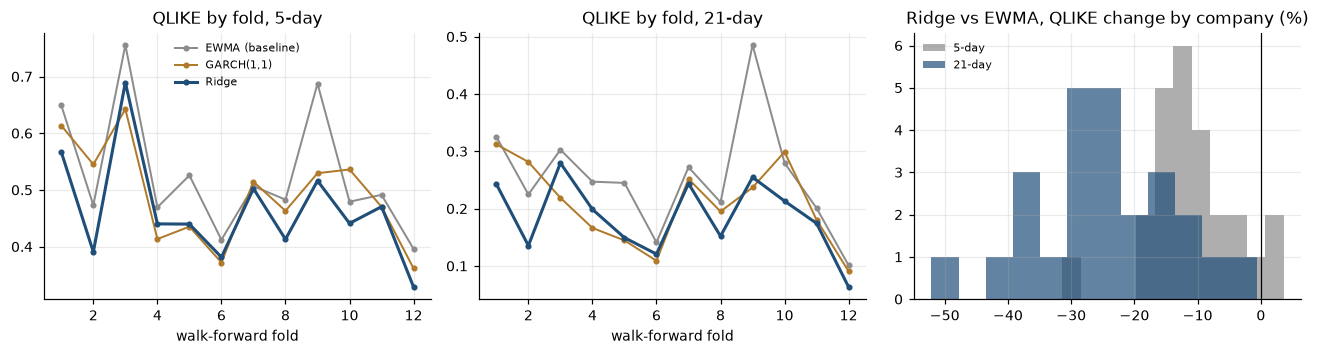

5-day: ridge has lower QLIKE than EWMA for 23 of 25 companies; change ranges from -31.4% to +3.6% (median -11.4%).
21-day: ridge has lower QLIKE than EWMA for 25 of 25 companies; change ranges from -52.1% to -0.7% (median -24.3%).


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
for ax, horizon in zip(axes[:2], (5, 21)):
    q = by_fold[(by_fold["horizon"] == horizon) & (by_fold["metric"] == "qlike")].pivot(
        index="fold", columns="model", values="value")
    for model, colour in (("ewma", GREY), ("garch", "#b07a2a"), ("ridge", ACCENT)):
        ax.plot(q.index, q[model], marker="o", ms=3, lw=1.3 if model != "ridge" else 2,
                color=colour, label=labels[model])
    ax.set_title(f"QLIKE by fold, {horizon}-day"); ax.set_xlabel("walk-forward fold")
axes[0].legend(frameon=False, fontsize=7)
t = by_ticker[by_ticker["metric"] == "qlike"].pivot_table(index=["horizon", "ticker"],
                                                         columns="model", values="value")
change = (t["ridge"] / t["ewma"] - 1) * 100
for horizon, colour in ((5, GREY), (21, ACCENT)):
    axes[2].hist(change.loc[horizon], bins=12, alpha=0.7, color=colour, label=f"{horizon}-day")
axes[2].axvline(0, color="black", lw=0.8); axes[2].legend(frameon=False, fontsize=7)
axes[2].set_title("Ridge vs EWMA, QLIKE change by company (%)")
plt.tight_layout(); plt.show()
for horizon in (5, 21):
    c = change.loc[horizon]
    print(f"{horizon}-day: ridge has lower QLIKE than EWMA for {int((c < 0).sum())} of {len(c)} "
          f"companies; change ranges from {c.min():+.1f}% to {c.max():+.1f}% "
          f"(median {c.median():+.1f}%).")

### 3.3 Is the difference statistically significant?

In [5]:
table = pd.DataFrame({
    "horizon": dm["horizon"], "forecaster": dm["model"].map(labels),
    "vs": dm["benchmark"].map(labels), "DM statistic": dm["dm_statistic"].round(2),
    "p-value": dm["p_value"].round(4),
    "companies significantly better": [f"{b} of {t}" for b, t in
                                       zip(dm["tickers_significantly_better"],
                                           dm["tickers_tested"])],
    "significantly worse": dm["tickers_significantly_worse"]})
print(table.to_string(index=False))

 horizon                 forecaster              vs  DM statistic  p-value companies significantly better  significantly worse
       5 Trailing 21-day (baseline) EWMA (baseline)          7.31   0.0000                        0 of 25                   14
       5                 GARCH(1,1) EWMA (baseline)         -2.48   0.0135                        8 of 25                    0
       5                      Ridge EWMA (baseline)         -4.72   0.0000                       13 of 25                    0
       5          Gradient boosting EWMA (baseline)         -3.20   0.0014                        5 of 25                    0
      21 Trailing 21-day (baseline) EWMA (baseline)          7.17   0.0000                        0 of 25                   20
      21                 GARCH(1,1) EWMA (baseline)         -2.28   0.0229                        8 of 25                    0
      21                      Ridge EWMA (baseline)         -4.03   0.0001                       11 of 25      

### 3.4 What a forecast looks like

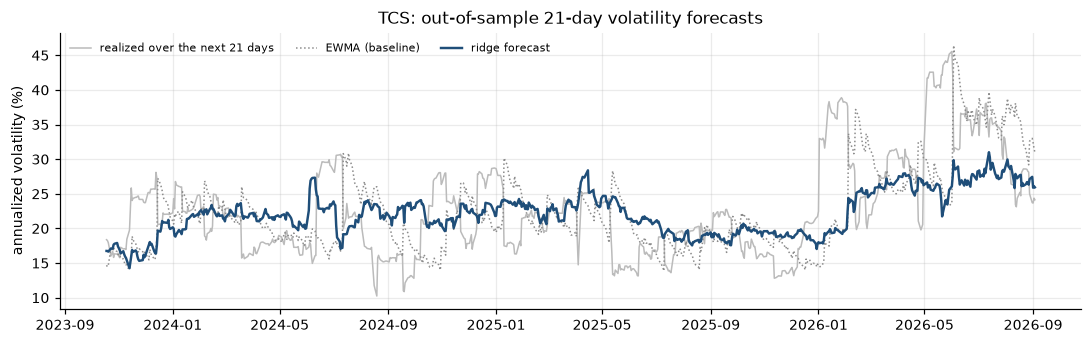

TCS, 709 forecasts: RMSE ridge 0.0637, EWMA 0.0711, GARCH 0.0718, trailing 21-day 0.0756.
Forecast range: ridge 14.3% to 31.0%; realized 10.3% to 45.6%.


In [6]:
TICKER = "TCS.NS"
with get_engine().connect() as conn:
    f = queries.load_ml_forecasts(conn, TICKER, 21)
f["date"] = pd.to_datetime(f["date"])
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(f["date"], f["realized"] * 100, color="#bbbbbb", lw=1, label="realized over the next 21 days")
ax.plot(f["date"], f["ewma"] * 100, color=GREY, lw=1, ls=":", label="EWMA (baseline)")
ax.plot(f["date"], f["ridge"] * 100, color=ACCENT, lw=1.6, label="ridge forecast")
ax.set_ylabel("annualized volatility (%)"); ax.legend(frameon=False, fontsize=7, ncol=3)
ax.set_title(f"{short(TICKER)}: out-of-sample 21-day volatility forecasts"); plt.tight_layout()
plt.show()
err = lambda col: float(np.sqrt(((f[col] - f["realized"]) ** 2).mean()))
print(f"{short(TICKER)}, {len(f)} forecasts: RMSE ridge {err('ridge'):.4f}, EWMA {err('ewma'):.4f}, "
      f"GARCH {err('garch'):.4f}, trailing 21-day {err('hist_21'):.4f}.")
print(f"Forecast range: ridge {f['ridge'].min():.1%} to {f['ridge'].max():.1%}; realized "
      f"{f['realized'].min():.1%} to {f['realized'].max():.1%}.")

## 4. Interpretation

- All three models have lower loss than the better baseline (EWMA) at both horizons, on every metric. Ridge is best; the more flexible gradient-boosted model is not better than the linear one.
- The improvement holds across time: the fold table shows how many of the twelve quarterly folds each model wins, and the fold standard deviation shows how much the loss itself varies from quarter to quarter (more than the gap between models in some folds).
- Pooled across companies the improvement is statistically significant. Company by company it is significant for about half, so the claim that holds is about the pooled panel, not about every stock.
- The gain is larger at 21 days. EWMA is built as a one-day-ahead estimate and is noisy as a forecast of a month's volatility; a model that blends several horizons smooths that noise. The chart shows the typical pattern: forecasts track the level and miss the spikes, which no method here anticipates.

## 5. Limitations

- One three-year test period in one market; rankings may differ in another regime.
- Realized variance from daily returns is a noisy proxy for true variance, especially over 5 days.
- No hyperparameter tuning: honest, but probably not the best achievable accuracy.
- Pooled coefficients ignore company-specific dynamics.
- Daily h-day forecasts overlap, so the effective sample is smaller than the row count; the test statistic allows for it.
- This must not be used to predict prices or returns, or to time trades.

*FinSight is an analytics tool, not investment advice.*